In [3]:
!pip install -r requirements.txt

In [4]:
import wandb
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from scipy.stats import ks_2samp, chi2_contingency
import yaml
import random
import matplotlib.pyplot as plt
import kagglehub
import shutil
import os
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset



def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [5]:
from key import KEY
API_KEY=KEY
wandb.login(API_KEY)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\joaod\_netrc
wandb: Currently logged in as: joao-silva-121 (tomazfil-team) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [6]:
config = {
    "data": {
        "raw_path": "data/raw/dataset.csv",
        "test_size": 0.2,
        "random_state": 42,
        "target_col": "Hazardous",
        "feature_cols": ['Orbit Uncertainity', 'Absolute Magnitude', 'Minimum Orbit Intersection', 'Name', 'Neo Reference ID', 'Orbit ID'],
        "missing_threshold": 0.5,
        "imputation_strategy": "mean"
    },
    "model": {
        "hidden_sizes": [64, 32],
        "dropout": 0.2,
        "learning_rate": 0.001,
        "batch_size": 32,
        "epochs": 100,
        "early_stopping_patience": 10
    }
}

In [7]:
path = kagglehub.dataset_download("lovishbansal123/nasa-asteroids-classification")
print(f'Baixado para: {path}')

destination = os.path.join(os.getcwd(), "dataset")

shutil.copytree(path, destination, dirs_exist_ok=True)
df_raw = pd.read_csv("dataset/nasa.csv", low_memory=False)

print(f"Linhas: {df_raw.shape}")
print(f"Colunas: {list(df_raw.columns)}")


df_raw.head()

Baixado para: C:\Users\joaod\.cache\kagglehub\datasets\lovishbansal123\nasa-asteroids-classification\versions\1
Linhas: (4687, 40)
Colunas: ['Neo Reference ID', 'Name', 'Absolute Magnitude', 'Est Dia in KM(min)', 'Est Dia in KM(max)', 'Est Dia in M(min)', 'Est Dia in M(max)', 'Est Dia in Miles(min)', 'Est Dia in Miles(max)', 'Est Dia in Feet(min)', 'Est Dia in Feet(max)', 'Close Approach Date', 'Epoch Date Close Approach', 'Relative Velocity km per sec', 'Relative Velocity km per hr', 'Miles per hour', 'Miss Dist.(Astronomical)', 'Miss Dist.(lunar)', 'Miss Dist.(kilometers)', 'Miss Dist.(miles)', 'Orbiting Body', 'Orbit ID', 'Orbit Determination Date', 'Orbit Uncertainity', 'Minimum Orbit Intersection', 'Jupiter Tisserand Invariant', 'Epoch Osculation', 'Eccentricity', 'Semi Major Axis', 'Inclination', 'Asc Node Longitude', 'Orbital Period', 'Perihelion Distance', 'Perihelion Arg', 'Aphelion Dist', 'Perihelion Time', 'Mean Anomaly', 'Mean Motion', 'Equinox', 'Hazardous']


,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Equinox,Hazardous
0,3703080,3703080,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,J2000,True
1,3723955,3723955,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,J2000,False
2,2446862,2446862,20.3,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,J2000,True
3,3092506,3092506,27.4,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,J2000,False
4,3514799,3514799,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,J2000,True


In [8]:
wandb.init(
    project="MLOps-Work",
    job_type="load_raw",
    name="load_raw"
)

artifact = wandb.Artifact(
    name="raw_data",
    type="dataset",
    description="nasa-asteroids-classification"
)
temp_path = "temp_raw.csv"
df_raw.to_csv(temp_path, index=False)
artifact.add_file(temp_path)

wandb.log_artifact(artifact)

wandb.summary["rows"] = len(df_raw)
wandb.summary["columns"] = list(df_raw.columns)

wandb.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


rows,4687


In [9]:
# Transformando o True em 1 e False em 0.
df_raw['Hazardous'] = df_raw['Hazardous'].replace({True: 1, False: 0})

df_raw.head()


,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Equinox,Hazardous
0,3703080,3703080,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,J2000,1
1,3723955,3723955,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,J2000,0
2,2446862,2446862,20.3,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,J2000,1
3,3092506,3092506,27.4,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,J2000,0
4,3514799,3514799,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,J2000,1


In [10]:
# Removendo a coluna: "Equinox" e "Orbiting body"

df = df_raw.drop(['Equinox', 'Orbiting Body'], axis=1)
df.head()

,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),...,Inclination,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Hazardous
0,3703080,3703080,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,6.025981,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,1
1,3723955,3723955,21.3,0.146068,0.326618,146.067964,326.617897,0.090762,0.202951,479.225620,...,28.412996,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,0
2,2446862,2446862,20.3,0.231502,0.517654,231.502122,517.654482,0.143849,0.321655,759.521423,...,4.237961,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,1
3,3092506,3092506,27.4,0.008801,0.019681,8.801465,19.680675,0.005469,0.012229,28.876199,...,7.905894,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,0
4,3514799,3514799,21.6,0.127220,0.284472,127.219879,284.472297,0.079051,0.176763,417.388066,...,16.793382,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,1


In [11]:
cols_to_drop = [
    'Neo Reference ID', 'Name', 'Orbit ID',
    'Est Dia in M(min)', 'Est Dia in M(max)',
    'Est Dia in Miles(min)', 'Est Dia in Miles(max)',
    'Est Dia in Feet(min)', 'Est Dia in Feet(max)',
    'Relative Velocity km per hr', 'Miles per hour',
    'Miss Dist.(Astronomical)', 'Miss Dist.(lunar)', 'Miss Dist.(miles)'
]

df = df.drop(columns=cols_to_drop, errors='ignore')
df.head()

,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Close Approach Date,Epoch Date Close Approach,Relative Velocity km per sec,Miss Dist.(kilometers),Orbit Determination Date,Orbit Uncertainity,Minimum Orbit Intersection,...,Inclination,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion,Hazardous
0,21.6,0.127220,0.284472,1995-01-01,788947200000,6.115834,62753692.0,2017-04-06 08:36:37,5,0.025282,...,6.025981,314.373913,609.599786,0.808259,57.257470,2.005764,2.458162e+06,264.837533,0.590551,1
1,21.3,0.146068,0.326618,1995-01-01,788947200000,18.113985,57298148.0,2017-04-06 08:32:49,3,0.186935,...,28.412996,136.717242,425.869294,0.718200,313.091975,1.497352,2.457795e+06,173.741112,0.845330,0
2,20.3,0.231502,0.517654,1995-01-08,789552000000,7.590711,7622911.5,2017-04-06 09:20:19,0,0.043058,...,4.237961,259.475979,643.580228,0.950791,248.415038,1.966857,2.458120e+06,292.893654,0.559371,1
3,27.4,0.008801,0.019681,1995-01-15,790156800000,11.173874,42683616.0,2017-04-06 09:15:49,6,0.005512,...,7.905894,57.173266,514.082140,0.983902,18.707701,1.527904,2.457902e+06,68.741007,0.700277,0
4,21.6,0.127220,0.284472,1995-01-15,790156800000,9.840831,61010824.0,2017-04-06 08:57:58,1,0.034798,...,16.793382,84.629307,495.597821,0.967687,158.263596,1.483543,2.457814e+06,135.142133,0.726395,1


In [12]:
def remove_duplicates(df: pd.DataFrame) -> pd.DataFrame:
    before = len(df)
    df = df.drop_duplicates()
    removidas = before - len(df)
    print(f'Removidas: {removidas} linhas duplicadas'
          f"({removidas / before:.1%} of dataset)")
    return df
df_clean = remove_duplicates(df_raw)

Removidas: 0 linhas duplicadas(0.0% of dataset)


In [13]:
def handle_missing_values(df, strategy='mean', threshold=0.5):
    missing_frac = df.isnull().mean()
    cols_to_drop = missing_frac[missing_frac > threshold].index.tolist()
    df = df.drop(columns=cols_to_drop)
    print(f"Dropped columns: {cols_to_drop}")
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    imputer = SimpleImputer(strategy=strategy)
    df[numeric_cols] = imputer.fit_transform(df[numeric_cols])
    cat_cols = df.select_dtypes(include=['object']).columns
    df[cat_cols] = df[cat_cols].fillna('missing')
    return df

df_clean = remove_duplicates(df_raw)
df_clean = handle_missing_values(df_clean, 
                                 strategy=config['data']['imputation_strategy'],
                                 threshold=config['data']['missing_threshold'])
print(f"Dataset limpo: {len(df_clean)} amostras")

wandb.init(project="MLOps-Work", job_type="clean_data", name="clean_data")
artifact = wandb.Artifact("clean_data", type="dataset")
temp_path = "temp_clean.csv"
df_clean.to_csv(temp_path, index=False)
artifact.add_file(temp_path)
wandb.log_artifact(artifact)
wandb.summary["rows"] = len(df_clean)
wandb.finish()

Removidas: 0 linhas duplicadas(0.0% of dataset)
Dropped columns: []
Dataset limpo: 4687 amostras


C:\Users\joaod\AppData\Local\Temp\ipykernel_14280\3768166823.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


rows,4687


In [14]:
wandb.init(
    project="MLOps-Work",
    job_type="clean_data",
    name="clean_data"
)

artifact = wandb.Artifact(
    name="clean_data",
    type="dataset",
    description="nasa-asteroids-classification after remove duplicates and missing values"
)
temp_path = "temp_clean.csv"
df_raw.to_csv(temp_path, index=False)
artifact.add_file(temp_path)

wandb.log_artifact(artifact)

wandb.summary["rows"] = len(df_clean)
wandb.summary["dropped_columns"] = df_clean.shape[1]

wandb.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


dropped_columns,40
rows,4687


In [15]:
def split_train_test(df, target_col, feature_cols, test_size=0.2, random_state=42):
    X = df[feature_cols]
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    train_df = pd.concat([X_train, y_train], axis=1)
    test_df = pd.concat([X_test, y_test], axis=1)
    return train_df, test_df

def compare_distributions(train_df, test_df, columns):
    results = {} 
    for col in columns:
        train_vals = train_df[col].dropna()
        test_vals = test_df[col].dropna()
        if train_df[col].dtype in ['int64', 'float64']:
            ks_stat, p_value = ks_2samp(train_vals, test_vals)
            results[col] = {'test': 'KS', 'statistic': ks_stat, 'p_value': p_value}
        else:
            train_counts = train_vals.value_counts(normalize=True)
            test_counts = test_vals.value_counts(normalize=True)
            all_cats = sorted(set(train_counts.index).union(set(test_counts.index)))
            train_probs = [train_counts.get(cat, 0) for cat in all_cats]
            test_probs = [test_counts.get(cat, 0) for cat in all_cats]
            chi2, p_value, _, _ = chi2_contingency([train_probs, test_probs])
            results[col] = {'test': 'Chi2', 'statistic': chi2, 'p_value': p_value}
    return results

train_df, test_df = split_train_test(df_clean,
                                     target_col=config['data']['target_col'],
                                     feature_cols=config['data']['feature_cols'],
                                     test_size=config['data']['test_size'],
                                     random_state=config['data']['random_state'])

print(f"Treino: {len(train_df)} amostras")
print(f"Teste:  {len(test_df)} amostras")


feature_cols = config['data']['feature_cols']
comp_results = compare_distributions(train_df, test_df, feature_cols)

wandb.init(project="MLOps-Work", job_type="split_data", name="split_data")

train_artifact = wandb.Artifact("train_data", type="dataset")
train_df.to_csv("temp_train.csv", index=False)
train_artifact.add_file("temp_train.csv")
wandb.log_artifact(train_artifact)

test_artifact = wandb.Artifact("test_data", type="dataset")
test_df.to_csv("temp_test.csv", index=False)
test_artifact.add_file("temp_test.csv")
wandb.log_artifact(test_artifact)

comp_df = pd.DataFrame(comp_results).T
comp_table = wandb.Table(dataframe=comp_df)
wandb.log({"distribution_comparison": comp_table})

wandb.summary["train_size"] = len(train_df)
wandb.summary["test_size"] = len(test_df)

wandb.finish()
print("Artefatos de treino e teste salvos com sucesso.")

Treino: 3749 amostras
Teste:  938 amostras


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


test_size,938
train_size,3749


Artefatos de treino e teste salvos com sucesso.


## 8. Modelo MLP: Definição e Matemática

### 🧠 Explicação Matemática da MLP

Uma **Multi‑Layer Perceptron (MLP)** é uma rede neural feedforward composta por:
* **Camada de entrada**: recebe os vetores de características.
* **Camadas ocultas**: cada neurônio aplica uma transformação afim seguida de uma função de ativação não linear.
* **Camada de saída**: produz a previsão final.

Para uma camada $l$ com $n$ neurônios:
- **Entrada**: $\mathbf{x}^{(l)} \in \mathbb{R}^{n_{in}}$
- **Pesos**: $\mathbf{W}^{(l)} \in \mathbb{R}^{n_{out} \times n_{in}}$
- **Bias**: $\mathbf{b}^{(l)} \in \mathbb{R}^{n_{out}}$
- **Ativação**: $\mathbf{z}^{(l)} = \mathbf{W}^{(l)} \mathbf{x}^{(l)} + \mathbf{b}^{(l)}$  
  $\mathbf{a}^{(l)} = f(\mathbf{z}^{(l)})$  (ex.: ReLU)

Na **classificação binária**, a camada de saída usa a função sigmoide para produzir uma probabilidade:

$$\hat{y} = \sigma(\mathbf{W}^{(L)} \mathbf{a}^{(L-1)} + \mathbf{b}^{(L)})$$

O treinamento minimiza a **entropia cruzada binária**:

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^N \left[ y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i) \right]$$

A atualização dos pesos é feita via **backpropagation** com **Adam** (variante do gradiente descendente).

### Implementação em PyTorch


===== MODELO 1 =====


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
train_loss,█▄▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▅▆▇▇███▇████████▇██████████████████████
val_loss,█▅▄▃▂▂▂▂▂▁▁▁▁▁▁▁▁▂▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,46
train_loss,0.01631
val_acc,0.99041
val_loss,0.02825


Early stopping na época 40

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99       791
         1.0       0.97      0.98      0.97       147

    accuracy                           0.99       938
   macro avg       0.98      0.99      0.98       938
weighted avg       0.99      0.99      0.99       938


=== TESTE DE NÃO-DECORAÇÃO ===
    Métrica      Real   Shuffle
0  Accuracy  0.991471  0.744136
1  F1-score  0.991495  0.744839


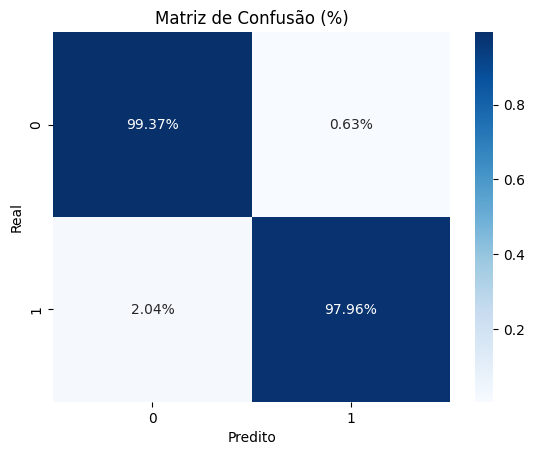

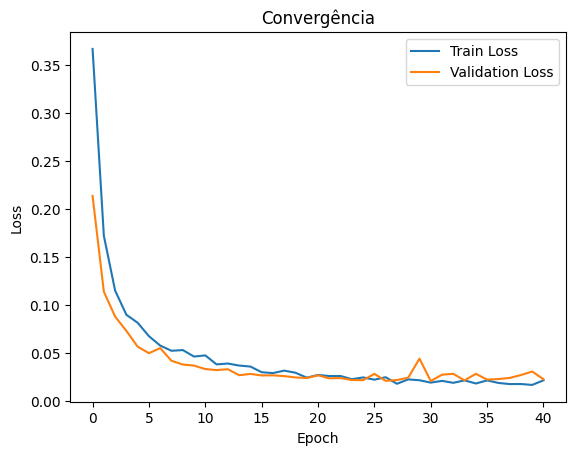

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
train_loss,█▄▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▆▆▇▇█▇▇█▇███████████████████▇██████████
val_loss,█▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁
epoch,40
train_loss,0.02186
val_acc,0.99254
val_loss,0.02298



===== MODELO 2 =====


Early stopping na época 80

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99       791
         1.0       0.97      0.98      0.97       147

    accuracy                           0.99       938
   macro avg       0.98      0.99      0.98       938
weighted avg       0.99      0.99      0.99       938


=== TESTE DE NÃO-DECORAÇÃO ===
    Métrica      Real   Shuffle
0  Accuracy  0.991471  0.739872
1  F1-score  0.991495  0.740586


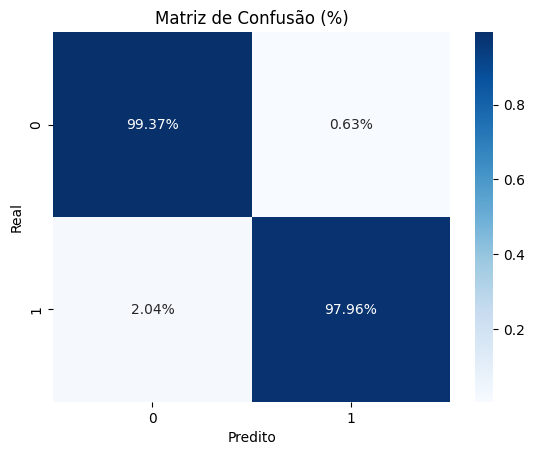

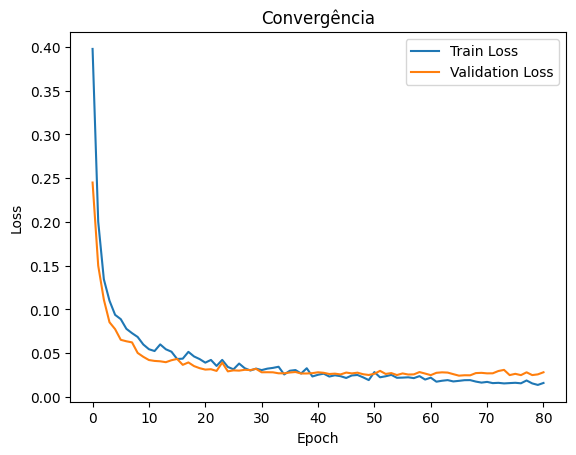

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
train_loss,█▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▆▇▇▇█▇▇▇▇█████████████████████████████
val_loss,█▅▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,80
train_loss,0.0159
val_acc,0.99147
val_loss,0.02813



=== COMPARAÇÃO ENTRE MODELOS ===
  modelo hidden_sizes      lr  dropout  accuracy        f1  f1_shuffle
0     M1     [64, 32]  0.0010      0.2  0.991471  0.991495    0.744839
1     M2    [128, 64]  0.0005      0.3  0.991471  0.991495    0.740586


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


In [20]:
def prepare_dataloaders(train_df, test_df, target_col, batch_size):
    X_train = train_df.drop(columns=[target_col]).values.astype(np.float32)
    y_train = train_df[target_col].values.astype(np.float32).reshape(-1, 1)

    X_test = test_df.drop(columns=[target_col]).values.astype(np.float32)
    y_test = test_df[target_col].values.astype(np.float32).reshape(-1, 1)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
    test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader


class MLP(nn.Module):
    def __init__(self, input_dim, hidden_sizes, dropout):
        super().__init__()
        layers = []
        prev = input_dim

        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev = h

        layers.append(nn.Linear(prev, 1))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

def train_model(config, train_loader, test_loader, input_dim):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MLP(input_dim, config['hidden_sizes'], config['dropout']).to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])

    best_loss = float('inf')
    patience = config['early_stopping_patience']
    counter = 0

    train_losses = []
    val_losses = []

    wandb.watch(model, log="all")

    for epoch in range(config['epochs']):
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)

        # validação
        model.eval()
        val_loss = 0.0
        correct = 0

        all_preds = []
        all_targets = []

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                output = model(X_batch)
                loss = criterion(output, y_batch)
                val_loss += loss.item() * X_batch.size(0)

                probs = torch.sigmoid(output)
                preds = (probs > 0.5).float()

                correct += (preds == y_batch).sum().item()

                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(y_batch.cpu().numpy())

        val_loss /= len(test_loader.dataset)
        acc = correct / len(test_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        wandb.log({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_acc": acc
        })

        if val_loss < best_loss:
            best_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), "best_model.pt")
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping na época {epoch}")
                break

    # carregar melhor modelo
    model.load_state_dict(torch.load("best_model.pt"))

    # avaliação final
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)

            output = model(X_batch)
            probs = torch.sigmoid(output)
            preds = (probs > 0.5).float()

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.numpy())

    y_pred = np.array(all_preds).flatten()
    y_test = np.array(all_targets).flatten()

    # métricas reais
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # =========================
    # TESTE DE NÃO-DECORAÇÃO
    # =========================
    y_shuffle = np.random.permutation(y_test)

    acc_shuffle = accuracy_score(y_shuffle, y_pred)
    f1_shuffle = f1_score(y_shuffle, y_pred, average='weighted')

    overfit_df = pd.DataFrame({
        "Métrica": ["Accuracy", "F1-score"],
        "Real": [acc, f1],
        "Shuffle": [acc_shuffle, f1_shuffle]
    })

    print("\n=== TESTE DE NÃO-DECORAÇÃO ===")
    print(overfit_df)

    wandb.log({
        "overfit_check": wandb.Table(dataframe=overfit_df)
    })

    # matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure()
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues')
    plt.title("Matriz de Confusão (%)")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.savefig("confusion_matrix.png")
    plt.show()

    wandb.log({
        "confusion_matrix": wandb.plot.confusion_matrix(
            probs=None,
            y_true=y_test,
            preds=y_pred
        )
    })

    # gráfico de convergência
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Convergência")
    plt.savefig("loss_curve.png")
    plt.show()

    wandb.log({"loss_curve": wandb.Image("loss_curve.png")})

    return {
        "model": model,
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "f1_shuffle": f1_shuffle
    }


# =========================
# EXECUÇÃO
# =========================
train_df = pd.read_csv("temp_train.csv")
test_df = pd.read_csv("temp_test.csv")

configs = [
    {"hidden_sizes":[64,32], "dropout":0.2, "learning_rate":0.001, "epochs":200, "early_stopping_patience":10},
    {"hidden_sizes":[128,64], "dropout":0.3, "learning_rate":0.0005, "epochs":200, "early_stopping_patience":15},
]

all_results = []

for i, cfg in enumerate(configs):
    print(f"\n===== MODELO {i+1} =====")

    wandb.init(project="MLOps-Work", name=f"model_{i+1}", config=cfg, reinit=True)

    train_loader, test_loader = prepare_dataloaders(
        train_df, test_df, target_col="Hazardous", batch_size=32
    )

    input_dim = train_loader.dataset.tensors[0].shape[1]

    result = train_model(cfg, train_loader, test_loader, input_dim)

    all_results.append({
        "modelo": f"M{i+1}",
        "hidden_sizes": cfg["hidden_sizes"],
        "lr": cfg["learning_rate"],
        "dropout": cfg["dropout"],
        "accuracy": result["accuracy"],
        "f1": result["f1"],
        "f1_shuffle": result["f1_shuffle"]
    })

    wandb.finish()

# tabela final
df_results = pd.DataFrame(all_results)

print("\n=== COMPARAÇÃO ENTRE MODELOS ===")
print(df_results)

wandb.init(project="MLOps-Work", name="comparison")
wandb.log({"comparison_table": wandb.Table(dataframe=df_results)})
wandb.finish()